# Problem 1: Steady One-Dimensional Convection-Diffusion Problem

In this problem, a scalar temperature field is transported by both convection and diffusion in a one-dimensional domain. Dirichlet boundary conditions are imposed at both ends of the domain.

The purpose of this problem is to compare the behavior of three convection schemes:

- Upwind Differencing Scheme (UDS)
- Central Differencing Scheme (CDS)
- QUICK scheme

The numerical solutions are compared with the analytical solution, and a grid-independence study is performed using 10, 20, 40, and 80 control volumes.

first of all we import python files provided in losson4 directory

In [101]:
import numpy as np
import matplotlib.pyplot as plt

from Grid import Grid
from ScalarCoeffs import ScalarCoeffs
from BoundaryConditions import DirichletBc, NeumannBc, BoundaryLocation
from LinearSolver import solve
from Models import DiffusionModel, SurfaceConvectionModel

## Advection Model

The provided framework contains models for diffusion, transient storage, and boundary conditions. However, it does not contain a model for convective transport.

To solve the convection-diffusion equation, an advection model is implemented below. The implementation follows the approach presented in Lesson 4, where the advection flux is evaluated at the cell faces and added to the finite-volume coefficient arrays.

Three convection schemes are considered:

- Upwind Differencing Scheme (UDS)
- Central Differencing Scheme (CDS)
- Quadratic Upwind Interpolation for Convective Kinematics (QUICK)

The UDS formulation is used for the implicit linearization because it guarantees bounded and stable coefficients. The CDS and QUICK schemes are implemented using deferred correction, allowing higher-order accuracy while preserving the stability of the UDS formulation.

In [102]:
class AdvectionModel:
    """Class defining a 1D advection model.

    UDS is used for the linearization. CDS and QUICK are added using
    deferred correction so that the higher-order schemes can be compared
    while keeping the stable UDS coefficient structure.
    """

    def __init__(
        self,
        grid,
        phi,
        Uhe,
        rho,
        cp,
        west_bc,
        east_bc,
        scheme="UDS",
        west_alpha=1.0,
        east_alpha=-1.0,
    ):
        """Constructor.

        Parameters
        ----------
        grid : Grid
            One-dimensional finite-volume grid.
        phi : ndarray
            Scalar field including boundary values.
        Uhe : ndarray
            Velocity values at the faces.
        rho : float
            Density.
        cp : float
            Specific heat capacity.
        west_bc, east_bc : boundary condition objects
            Boundary conditions at west and east sides.
        scheme : str
            Advection scheme: 'UDS', 'CDS', or 'QUICK'.
        west_alpha, east_alpha : float
            Boundary alpha values used to force the correct boundary face value.
        """

        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc
        self._scheme = scheme
        self._west_alpha = west_alpha
        self._east_alpha = east_alpha

        self._alphae = np.zeros(self._grid.ncv + 1)
        self._phie_uds = np.zeros(self._grid.ncv + 1)
        self._phie_hos = np.zeros(self._grid.ncv + 1)

    def add(self, coeffs):
        """Add advection terms to the coefficient arrays."""

        # Calculate UDS alpha values from the flow direction
        for i in range(self._grid.ncv + 1):
            if self._Uhe[i] >= 0:
                self._alphae[i] = 1.0
            else:
                self._alphae[i] = -1.0

        # Modify boundary alpha values as required by the assignment
        self._alphae[0] = self._west_alpha
        self._alphae[-1] = self._east_alpha

        # UDS face values
        self._phie_uds = (
            (1.0 + self._alphae) / 2.0 * self._phi[0:-1]
            + (1.0 - self._alphae) / 2.0 * self._phi[1:]
        )

        # Higher-order face values
        if self._scheme == "UDS":
            self._phie_hos[:] = self._phie_uds[:]

        elif self._scheme == "CDS":
            self._phie_hos[:] = 0.5 * (self._phi[0:-1] + self._phi[1:])

        elif self._scheme == "QUICK":
            self._phie_hos[:] = self._phie_uds[:]

            for i in range(1, self._grid.ncv):
                if self._Uhe[i] >= 0:
                    self._phie_hos[i] = (
                        -1.0 / 8.0 * self._phi[i - 1]
                        + 3.0 / 4.0 * self._phi[i]
                        + 3.0 / 8.0 * self._phi[i + 1]
                    )
                else:
                    self._phie_hos[i] = (
                        3.0 / 8.0 * self._phi[i]
                        + 3.0 / 4.0 * self._phi[i + 1]
                        - 1.0 / 8.0 * self._phi[i + 2]
                    )

        else:
            raise ValueError("Unknown scheme. Use 'UDS', 'CDS', or 'QUICK'.")

        # Use the UDS boundary values for all schemes
        self._phie_hos[0] = self._phie_uds[0]
        self._phie_hos[-1] = self._phie_uds[-1]

        # Face mass flow rates
        mdote = self._rho * self._Uhe * self._grid.Af

        # UDS fluxes for the implicit linearization
        flux_w_uds = self._cp * mdote[:-1] * self._phie_uds[:-1]
        flux_e_uds = self._cp * mdote[1:] * self._phie_uds[1:]

        # Higher-order fluxes for the residual
        flux_w_hos = self._cp * mdote[:-1] * self._phie_hos[:-1]
        flux_e_hos = self._cp * mdote[1:] * self._phie_hos[1:]

        # Mass imbalance correction
        imbalance = (
            -self._cp * mdote[1:] * self._phi[1:-1]
            + self._cp * mdote[:-1] * self._phi[1:-1]
        )

        # UDS linearization coefficients
        coeffW = -self._cp * mdote[:-1] * (1.0 + self._alphae[:-1]) / 2.0
        coeffE = self._cp * mdote[1:] * (1.0 - self._alphae[1:]) / 2.0
        coeffP = -coeffW - coeffE

        # Boundary coefficient treatment
        coeffP[0] += coeffW[0] * self._west_bc.coeff()
        coeffP[-1] += coeffE[-1] * self._east_bc.coeff()

        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Deferred correction
        flux_uds = flux_e_uds - flux_w_uds
        flux_hos = flux_e_hos - flux_w_hos
        correction = flux_hos - flux_uds

        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux_uds)
        coeffs.accumulate_rP(correction)
        coeffs.accumulate_rP(imbalance)

        return coeffs

## Problem Definition

We are solving the one-dimensional steady convection-diffusion equation across a domain of length
 $L = 1$.The boundary conditions are:$$T(0) = 0$$$$T(L) = 1$$We have chosen thermophysical properties so that the domain Peclet number is 50:$$Pe = \frac{\rho c_p u L}{k} = 50$$Because $Pe = 50$, this is a convection-dominated problem, making it an ideal test case to compare the performance of the UDS, CDS, and QUICK discretization schemes.

In [103]:
# Domain parameters
L = 1.0
ly = 1.0
lz = 1.0

# Grid
ncv = 10

# Flow properties
rho = 1.0
cp = 1.0
u = 1.0
k = 0.02

# Boundary temperatures
T1 = 0.0
T2 = 1.0

# Domain Peclet number
Pe = rho * cp * u * L / k

# Solver controls
maxIter = 200
converged = 1e-8

print(f"Pe = {Pe}")

Pe = 50.0


## Analytical Solution

The analytical solution for the steady one-dimensional convection-diffusion problem is

$$
T(x) = T_1 + 
\frac{\exp(Pe x/L)-1}{\exp(Pe)-1}
(T_2-T_1)
$$

This analytical solution is used as the reference solution for the numerical results. The maximum error and RMS error are calculated by comparing the numerical solution at the cell centers with the analytical solution at the same locations.

In [104]:
def analytical_solution(x, L, T1, T2, Pe):
    """Calculate the analytical solution for the 1D steady convection-diffusion problem."""
    
    return T1 + (T2 - T1) * (np.exp(Pe * x / L) - 1.0) / (np.exp(Pe) - 1.0)

## Numerical Solver Function

To make the results reproducible, the numerical solution is calculated inside a function. This avoids having results appear from code that was not clearly defined earlier in the notebook.

The function takes the number of control volumes and the advection scheme as inputs. It then builds the grid, applies the boundary conditions, adds the diffusion and advection models, and iterates until the residual is below the convergence tolerance.

In [105]:
def solve_problem1(ncv, scheme, maxIter=500, converged=1e-10):
    """Solve Problem 1 for a given grid size and advection scheme."""

    # Create grid
    grid = Grid(
        lx=L,
        ly=ly,
        lz=lz,
        ncv=ncv
    )

    # Initialize coefficient object
    coeffs = ScalarCoeffs(grid.ncv)

    # Initialize scalar field including boundary values
    T = np.linspace(T1, T2, grid.ncv + 2)

    # Face velocity array
    Uhe = u * np.ones(grid.ncv + 1)

    # Define boundary conditions
    west_bc = DirichletBc(T, grid, T1, BoundaryLocation.WEST)
    east_bc = DirichletBc(T, grid, T2, BoundaryLocation.EAST)

    # Apply boundary conditions
    west_bc.apply()
    east_bc.apply()

    # Define models
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    advection = AdvectionModel(
        grid=grid,
        phi=T,
        Uhe=Uhe,
        rho=rho,
        cp=cp,
        west_bc=west_bc,
        east_bc=east_bc,
        scheme=scheme,
        west_alpha=1.0,
        east_alpha=-1.0
    )

    # Nonlinear iteration
    for iteration in range(maxIter):
        coeffs.zero()

        coeffs = diffusion.add(coeffs)
        coeffs = advection.add(coeffs)

        maxResid = np.linalg.norm(coeffs.rP, np.inf)

        if maxResid < converged:
            break

        dT = solve(coeffs)

        T[1:-1] += dT

        west_bc.apply()
        east_bc.apply()

    # Analytical solution at cell centers
    T_exact = analytical_solution(grid.xP, L, T1, T2, Pe)

    # Error using internal cells only
    error = T[1:-1] - T_exact[1:-1]
    max_error = np.max(np.abs(error))
    rms_error = np.sqrt(np.mean(error**2))

    return grid, T, T_exact, max_error, rms_error, iteration + 1

## Comparison of Advection Schemes

The numerical solution is first calculated using 10 control volumes. The purpose of this test is to compare the behavior of the UDS, CDS, and QUICK schemes for a convection-dominated case with

$$
Pe = 50
$$

The same grid and physical properties are used for all three schemes.

In [106]:
schemes = ["UDS", "CDS", "QUICK"]

results = {}

for scheme in schemes:
    grid, T, T_exact, max_error, rms_error, iterations = solve_problem1(
        ncv=10,
        scheme=scheme
    )
    
    results[scheme] = {
        "grid": grid,
        "T": T,
        "T_exact": T_exact,
        "max_error": max_error,
        "rms_error": rms_error,
        "iterations": iterations
    }

    print(f"{scheme}: iterations = {iterations}, max error = {max_error:.6e}, RMS error = {rms_error:.6e}")

UDS: iterations = 2, max error = 1.582085e+00, RMS error = 5.067105e-01
CDS: iterations = 60, max error = 1.582608e+00, RMS error = 5.486540e-01
QUICK: iterations = 28, max error = 1.582085e+00, RMS error = 5.077394e-01


## Plot of Numerical and Analytical Solutions

The plot below compares the numerical solutions from the three advection schemes with the analytical solution. Since the Peclet number is large, the solution remains almost constant over most of the domain and changes sharply near the outlet boundary.

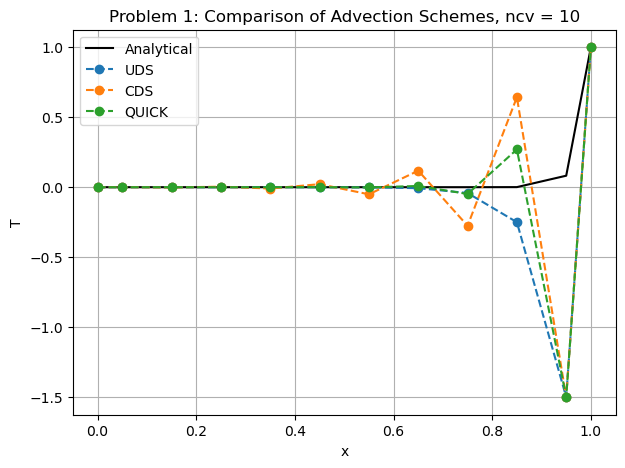

In [107]:
plt.figure(figsize=(7, 5))

plt.plot(
    results["UDS"]["grid"].xP,
    results["UDS"]["T_exact"],
    "k-",
    label="Analytical"
)

for scheme in schemes:
    plt.plot(
        results[scheme]["grid"].xP,
        results[scheme]["T"],
        marker="o",
        linestyle="--",
        label=scheme
    )

plt.xlabel("x")
plt.ylabel("T")
plt.title("Problem 1: Comparison of Advection Schemes, ncv = 10")
plt.legend()
plt.grid(True)
plt.show()

### Discussion of Results for 10 Control Volumes

For this case, the cell Peclet number is

$$
Pe_\Delta=\frac{50}{10}=5
$$

which indicates a strongly convection-dominated problem. The analytical solution remains close to zero throughout most of the domain and increases rapidly near the outlet.

All three schemes exhibit oscillations near the east boundary because the grid is too coarse to resolve the sharp outlet gradient. UDS converges rapidly but is more diffusive, while CDS and QUICK require more iterations due to the deferred-correction formulation.

Overall, 10 control volumes are insufficient to accurately resolve the solution, motivating the grid-independence study presented next.


## Grid-Independence Study

The calculation is repeated using

$$
N_{CV} = 10,\ 20,\ 40,\ 80
$$

The maximum error and RMS error are calculated for each grid. This provides a quantitative comparison between the numerical and analytical solutions, instead of relying only on plotted curves.

In [108]:
ncv_values = [10, 20, 40, 80]

grid_study = {}

for scheme in schemes:
    grid_study[scheme] = {
        "ncv": [],
        "max_error": [],
        "rms_error": [],
        "iterations": []
    }

    for ncv in ncv_values:
        grid, T, T_exact, max_error, rms_error, iterations = solve_problem1(
            ncv=ncv,
            scheme=scheme
        )

        grid_study[scheme]["ncv"].append(ncv)
        grid_study[scheme]["max_error"].append(max_error)
        grid_study[scheme]["rms_error"].append(rms_error)
        grid_study[scheme]["iterations"].append(iterations)

       
        import pandas as pd

rows = []

for scheme in schemes:
    for i, ncv in enumerate(grid_study[scheme]["ncv"]):
        rows.append([
            scheme,
            ncv,
            grid_study[scheme]["max_error"][i],
            grid_study[scheme]["rms_error"][i],
            grid_study[scheme]["iterations"][i]
        ])

df = pd.DataFrame(
    rows,
    columns=[
        "Scheme",
        "NCV",
        "Max Error",
        "RMS Error",
        "Iterations"
    ]
)

df

,Scheme,NCV,Max Error,RMS Error,Iterations
0,UDS,10,1.582085,0.506711,2
1,UDS,20,0.536505,0.121941,2
2,UDS,40,0.160261,0.026145,2
3,UDS,80,0.050744,0.011651,2
4,CDS,10,1.582608,0.548654,60
5,CDS,20,0.536505,0.119975,36
6,CDS,40,0.160261,0.027746,23
7,CDS,80,0.044116,0.006768,17
8,QUICK,10,1.582085,0.507739,28
9,QUICK,20,0.536505,0.120142,22


## Error Comparison

The following plots show how the maximum error and RMS error change as the grid is refined. A decreasing error with grid refinement indicates that the numerical solution is approaching the analytical solution.

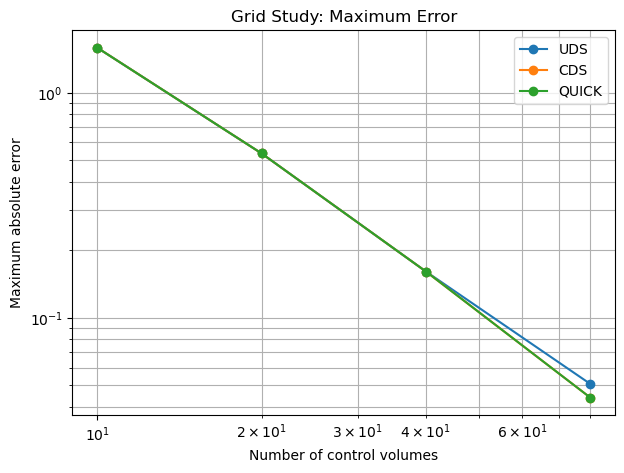

In [109]:
plt.figure(figsize=(7, 5))

for scheme in schemes:
    plt.loglog(
        grid_study[scheme]["ncv"],
        grid_study[scheme]["max_error"],
        marker="o",
        label=scheme
    )

plt.xlabel("Number of control volumes")
plt.ylabel("Maximum absolute error")
plt.title("Grid Study: Maximum Error")
plt.legend()
plt.grid(True, which="both")
plt.show()

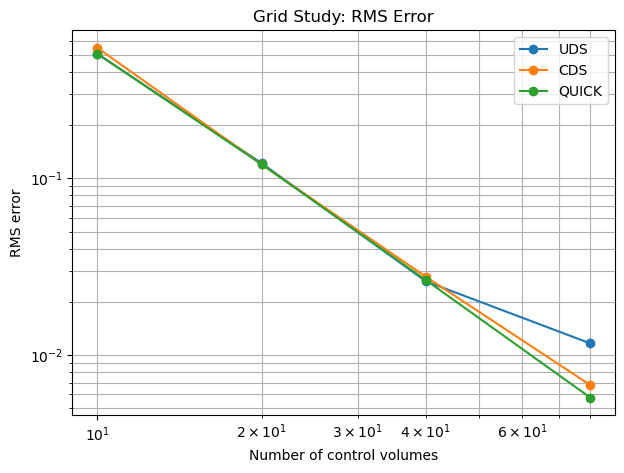

In [110]:
plt.figure(figsize=(7, 5))

for scheme in schemes:
    plt.loglog(
        grid_study[scheme]["ncv"],
        grid_study[scheme]["rms_error"],
        marker="o",
        label=scheme
    )

plt.xlabel("Number of control volumes")
plt.ylabel("RMS error")
plt.title("Grid Study: RMS Error")
plt.legend()
plt.grid(True, which="both")
plt.show()

### Discussion of Grid-Independence Results

The maximum and RMS errors decrease as the grid is refined, indicating convergence toward the analytical solution. The coarse-grid oscillations observed for 10 control volumes are significantly reduced on the finer meshes.

For the finest grid, QUICK produces the lowest RMS error, followed by CDS and UDS. This is consistent with the higher-order accuracy of QUICK and CDS compared with the first-order UDS scheme.

Overall, all schemes converge toward the analytical solution as the grid is refined, with QUICK providing the most accurate results on the finest mesh.


## Comparison of Advection Schemes for 80 Control Volumes

The numerical solutions obtained using 80 control volumes are shown below. 

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

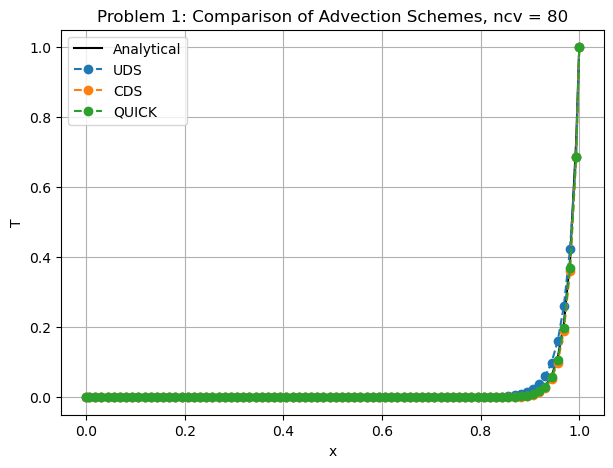

In [111]:
schemes = ["UDS", "CDS", "QUICK"]

results = {}

for scheme in schemes:
    grid, T, T_exact, max_error, rms_error, iterations = solve_problem1(
        ncv=80,
        scheme=scheme
    )
    
    results[scheme] = {
        "grid": grid,
        "T": T,
        "T_exact": T_exact,
        "max_error": max_error,
        "rms_error": rms_error,
        "iterations": iterations
    }
    plt.figure(figsize=(7, 5))

plt.plot(grid.xP, T_exact, "k-", label="Analytical")

for scheme in schemes:
    plt.plot(
        results[scheme]["grid"].xP,
        results[scheme]["T"],
        marker="o",
        linestyle="--",
        label=scheme
    )

plt.xlabel("x")
plt.ylabel("T")
plt.title("Problem 1: Comparison of Advection Schemes, ncv = 80")
plt.legend()
plt.grid(True)
plt.show()

Compared with the 10-control-volume case, the oscillations are significantly reduced and the numerical solutions are much closer to the analytical solution.

# Problem 2: Heated Square Duct

In this problem, water flows through a heated square duct. The inlet temperature is prescribed, and heat is added through external convection from the surrounding fluid.

The west boundary is treated as a Dirichlet inlet boundary. the east boundary is treated as a Neumann outlet boundary, not a Robin boundary.

In [112]:
# Problem 2 parameters

L2 = 5.0
ly2 = 0.01
lz2 = 0.01

rho2 = 1000.0
cp2 = 4189.0
k2 = 0.590

u2 = 1.5

Tin2 = 0.0
Tinf2 = 100.0
h2 = 10000.0

ncv2 = 5
dt2 = 1e10

maxIter2 = 500
converged2 = 1e-10

The exact solution for this problem is

$$
\frac{T_\infty - T(x)}{T_\infty - T_{in}}
=
\exp\left(-\frac{h P x}{\dot{m} c_p}\right)
$$

where \(P\) is the heated perimeter and \(\dot{m}\) is the mass flow rate. For the square duct,

$$
P = 2l_y + 2l_z
$$

and

$$
\dot{m} = \rho u A
$$

In [113]:
def analytical_solution_problem2(x, rho, cp, u, ly, lz, h, Tin, Tinf):
    """Analytical solution for heated square duct problem."""
    
    area = ly * lz
    perimeter = 2.0 * ly + 2.0 * lz
    mdot = rho * u * area
    
    return Tinf - (Tinf - Tin) * np.exp(-h * perimeter * x / (mdot * cp))

## Numerical Solver Function


In [114]:
def solve_problem2(u_value, west_value, east_gradient, west_alpha, east_alpha, scheme):
    """Solve Problem 2 for a given flow direction, boundary setup, and advection scheme."""

    # Create grid
    grid = Grid(
        lx=L2,
        ly=ly2,
        lz=lz2,
        ncv=ncv2
    )

    # Initialize coefficients
    coeffs = ScalarCoeffs(grid.ncv)

    # Initialize field variable arrays
    T = Tin2 * np.ones(grid.ncv + 2)
    Uhe = u_value * np.ones(grid.ncv + 1)

    # Define boundary conditions
    west_bc = DirichletBc(T, grid, west_value, BoundaryLocation.WEST)
    east_bc = NeumannBc(T, grid, east_gradient, BoundaryLocation.EAST)

    # Apply boundary conditions
    west_bc.apply()
    east_bc.apply()

    # Define models
    diffusion = DiffusionModel(
        grid=grid,
        phi=T,
        gamma=k2,
        west_bc=west_bc,
        east_bc=east_bc
    )

    surface_convection = SurfaceConvectionModel(
        grid=grid,
        T=T,
        ho=h2,
        To=Tinf2
    )

    advection = AdvectionModel(
        grid=grid,
        phi=T,
        Uhe=Uhe,
        rho=rho2,
        cp=cp2,
        west_bc=west_bc,
        east_bc=east_bc,
        scheme=scheme,
        west_alpha=west_alpha,
        east_alpha=east_alpha
    )

    # Iterate to convergence
    for iteration in range(maxIter2):
        coeffs.zero()

        coeffs = diffusion.add(coeffs)
        coeffs = surface_convection.add(coeffs)
        coeffs = advection.add(coeffs)

        maxResid = np.linalg.norm(coeffs.rP, np.inf)

        if maxResid < converged2:
            break

        dT = solve(coeffs)

        T[1:-1] += dT

        west_bc.apply()
        east_bc.apply()

    # Analytical solution
    T_exact = analytical_solution_problem2(
        x=grid.xP,
        rho=rho2,
        cp=cp2,
        u=abs(u_value),
        ly=ly2,
        lz=lz2,
        h=h2,
        Tin=Tin2,
        Tinf=Tinf2
    )

    return grid, T, T_exact, iteration + 1



The first calculation uses positive flow from west to east. Therefore, the west boundary acts as the inlet and the east boundary acts as a zero-gradient outlet.

In [115]:
problem2_schemes = ["UDS", "CDS", "QUICK"]

problem2_results = {}

for scheme in problem2_schemes:
    grid2, T2_num, T2_exact, iterations2 = solve_problem2(
        u_value=u2,
        west_value=Tin2,
        east_gradient=0.0,
        west_alpha=1.0,
        east_alpha=1.0,
        scheme=scheme
    )
    
    problem2_results[scheme] = {
        "grid": grid2,
        "T": T2_num,
        "T_exact": T2_exact,
        "iterations": iterations2
    }
    
    print(f"{scheme}: iterations = {iterations2}")

UDS: iterations = 2
CDS: iterations = 57
QUICK: iterations = 32


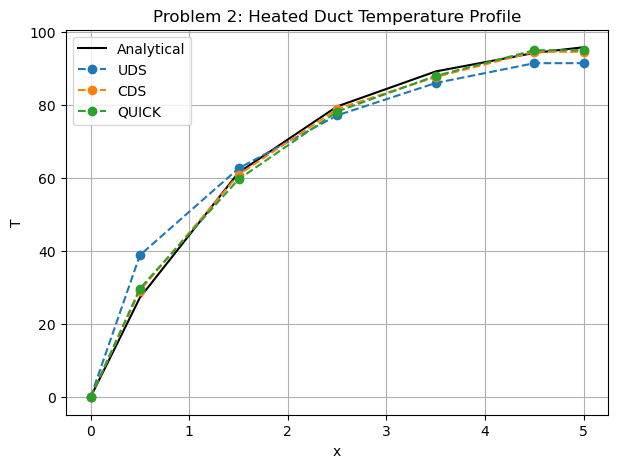

In [116]:
plt.figure(figsize=(7, 5))

plt.plot(grid2.xP, T2_exact, "k-", label="Analytical")

for scheme in problem2_schemes:
    plt.plot(
        problem2_results[scheme]["grid"].xP,
        problem2_results[scheme]["T"],
        marker="o",
        linestyle="--",
        label=scheme
    )

plt.xlabel("x")
plt.ylabel("T")
plt.title("Problem 2: Heated Duct Temperature Profile")
plt.legend()
plt.grid(True)
plt.show()

### Discussion

All three schemes capture the heating of the fluid as it flows through the duct. UDS converges fastest but is slightly more diffusive than CDS and QUICK. The outlet Neumann boundary condition produces a physically realistic outlet by allowing the temperature gradient to approach zero.

## Effect of East Boundary Alpha

The assignment asks to compare the result obtained with different values of the east boundary weighting factor. The east boundary is still treated as a zero-gradient Neumann outlet, but the value of alpha at the east face is changed.

In [117]:
east_alpha_values = [1.0, -1.0]

alpha_results = {}

for east_alpha in east_alpha_values:
    alpha_results[east_alpha] = {}

    for scheme in problem2_schemes:
        grid2, T2_num, T2_exact, iterations2 = solve_problem2(
            u_value=u2,
            west_value=Tin2,
            east_gradient=0.0,
            west_alpha=1.0,
            east_alpha=east_alpha,
            scheme=scheme
        )

        alpha_results[east_alpha][scheme] = {
            "grid": grid2,
            "T": T2_num,
            "T_exact": T2_exact,
            "iterations": iterations2
        }

        print(
            f"east_alpha = {east_alpha:+.1f}, "
            f"{scheme}: iterations = {iterations2}"
        )

east_alpha = +1.0, UDS: iterations = 2
east_alpha = +1.0, CDS: iterations = 57
east_alpha = +1.0, QUICK: iterations = 32
east_alpha = -1.0, UDS: iterations = 2
east_alpha = -1.0, CDS: iterations = 57
east_alpha = -1.0, QUICK: iterations = 32


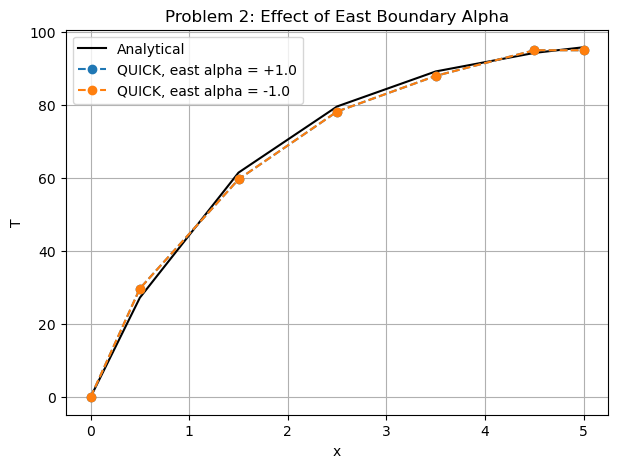

In [118]:
plt.figure(figsize=(7, 5))

plt.plot(grid2.xP, T2_exact, "k-", label="Analytical")

for east_alpha in east_alpha_values:
    plt.plot(
        alpha_results[east_alpha]["QUICK"]["grid"].xP,
        alpha_results[east_alpha]["QUICK"]["T"],
        marker="o",
        linestyle="--",
        label=f"QUICK, east alpha = {east_alpha:+.1f}"
    )

plt.xlabel("x")
plt.ylabel("T")
plt.title("Problem 2: Effect of East Boundary Alpha")
plt.legend()
plt.grid(True)
plt.show()

### Discussion

The effect of changing the east boundary value of alpha is negligible. The zero-gradient Neumann outlet dominates the boundary treatment, resulting in nearly identical temperature profiles.

## Reverse Flow Direction

The flow direction is now reversed. The inlet is located at the east boundary and the outlet is located at the west boundary. Therefore, the east boundary is prescribed using a Dirichlet condition and the west boundary is treated as a zero-gradient Neumann outlet.

In [119]:
def solve_problem2_reverse(west_gradient, east_value, west_alpha, east_alpha, scheme):
    """Solve Problem 2 with reversed flow direction."""

    grid = Grid(
        lx=L2,
        ly=ly2,
        lz=lz2,
        ncv=ncv2
    )

    coeffs = ScalarCoeffs(grid.ncv)

    T = Tin2 * np.ones(grid.ncv + 2)
    Uhe = -u2 * np.ones(grid.ncv + 1)

    west_bc = NeumannBc(T, grid, west_gradient, BoundaryLocation.WEST)
    east_bc = DirichletBc(T, grid, east_value, BoundaryLocation.EAST)

    west_bc.apply()
    east_bc.apply()

    diffusion = DiffusionModel(
        grid=grid,
        phi=T,
        gamma=k2,
        west_bc=west_bc,
        east_bc=east_bc
    )

    surface_convection = SurfaceConvectionModel(
        grid=grid,
        T=T,
        ho=h2,
        To=Tinf2
    )

    advection = AdvectionModel(
        grid=grid,
        phi=T,
        Uhe=Uhe,
        rho=rho2,
        cp=cp2,
        west_bc=west_bc,
        east_bc=east_bc,
        scheme=scheme,
        west_alpha=west_alpha,
        east_alpha=east_alpha
    )

    for iteration in range(maxIter2):
        coeffs.zero()

        coeffs = diffusion.add(coeffs)
        coeffs = surface_convection.add(coeffs)
        coeffs = advection.add(coeffs)

        maxResid = np.linalg.norm(coeffs.rP, np.inf)

        if maxResid < converged2:
            break

        dT = solve(coeffs)

        T[1:-1] += dT

        west_bc.apply()
        east_bc.apply()

    return grid, T, iteration + 1
    

In [120]:
reverse_results = {}

for scheme in problem2_schemes:
    grid2_reverse, T2_reverse, iterations2_reverse = solve_problem2_reverse(
        west_gradient=0.0,
        east_value=Tin2,
        west_alpha=-1.0,
        east_alpha=-1.0,
        scheme=scheme
    )

    reverse_results[scheme] = {
        "grid": grid2_reverse,
        "T": T2_reverse,
        "iterations": iterations2_reverse
    }

    print(f"{scheme}: iterations = {iterations2_reverse}")

UDS: iterations = 2
CDS: iterations = 57
QUICK: iterations = 32


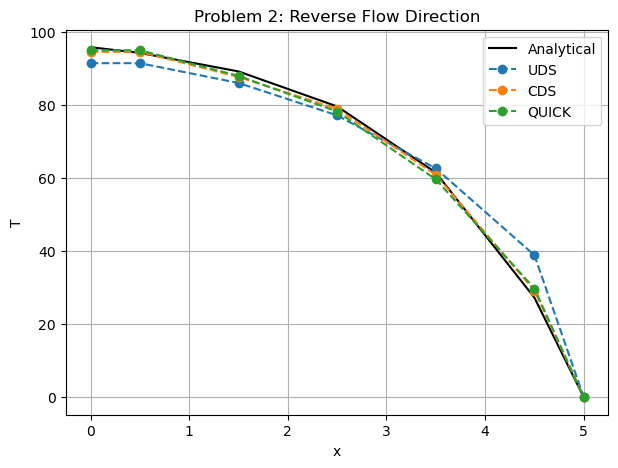

In [121]:
x_reverse_exact = grid2_reverse.xP
T_reverse_exact = analytical_solution_problem2(
    x=L2 - x_reverse_exact,
    rho=rho2,
    cp=cp2,
    u=u2,
    ly=ly2,
    lz=lz2,
    h=h2,
    Tin=Tin2,
    Tinf=Tinf2
)

plt.figure(figsize=(7, 5))

plt.plot(grid2_reverse.xP, T_reverse_exact, "k-", label="Analytical")

for scheme in problem2_schemes:
    plt.plot(
        reverse_results[scheme]["grid"].xP,
        reverse_results[scheme]["T"],
        marker="o",
        linestyle="--",
        label=scheme
    )

plt.xlabel("x")
plt.ylabel("T")
plt.title("Problem 2: Reverse Flow Direction")
plt.legend()
plt.grid(True)
plt.show()

### Discussion

Reversing the flow direction gives the same temperature profile as before, but reflected in the x-direction. The fluid now enters from the east boundary and heats up as it moves toward the west outlet.

UDS again converges fastest but is more diffusive than CDS and QUICK.

## General Statement About Boundary Alpha Values

The value of alpha at a boundary should be chosen based on the flow direction.

At an inlet, alpha should be selected so that the prescribed inlet temperature is carried into the domain. At an outlet, the boundary should not impose a new temperature value. Instead, the outlet temperature should be determined from the interior solution, especially when a zero-gradient Neumann boundary condition is used.

Therefore, for positive flow from west to east, alpha = +1 is appropriate at the east outlet. For negative flow from east to west, alpha = -1 is appropriate at the west outlet.